<a href="https://colab.research.google.com/github/fralfaro/MAT281_2024/blob/main/docs/labs/lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# MAT281 - Laboratorio N°10

<a id='p1'></a>
## I.- Problema 01

Lista de actos delictivos registrados por el Service de police de la Ville de Montréal (SPVM).


<img src="http://henriquecapriles.com/wp-content/uploads/2017/02/femina_detenida-1080x675.jpg" width="480" height="360" align="center"/>

El conjunto de datos en estudio `interventionscitoyendo.csv` corresponde a  todos los delitos entre 2015 y agosto de 2020en Montreal. Cada delito está asociado en grandes categorías, y hay información sobre la ubicación, el momento del día, etc.

> **Nota**: Para más información seguir el siguiente el [link](https://donnees.montreal.ca/ville-de-montreal/actes-criminels).

In [2]:
# librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX

# graficos incrustados
sns.set_style('whitegrid')
%matplotlib inline

# parametros esteticos de seaborn
sns.set_palette("deep", desat=.6)
sns.set_context(rc={"figure.figsize": (12, 4)})

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):
    """
    Aplicar las distintas métricas definidas
    :param df: DataFrame con las columnas: ['y', 'yhat']
    :return: DataFrame con las métricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]

    return df_result

In [4]:
# read data

validate_categorie = [
  'Introduction', 'Méfait','Vol dans / sur véhicule à moteur', 'Vol de véhicule à moteur',
]

df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/MAT281_2024/main/docs/labs/data/interventionscitoyendo.csv", sep=",", encoding='latin-1')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

df = df.loc[lambda x: x['categorie'].isin(validate_categorie)]
df = df.sort_values(['categorie','date'])
df.head()

,categorie,date,quart,pdq,x,y,longitude,latitude
3462,Introduction,2015-01-01,jour,42.0,297210.375006,5.050179e+06,-73.597273,45.591480
8370,Introduction,2015-01-01,soir,13.0,297145.531007,5.032845e+06,-73.597834,45.435501
11968,Introduction,2015-01-01,nuit,8.0,289215.072000,5.036423e+06,-73.699308,45.467564
12763,Introduction,2015-01-01,soir,27.0,293203.472992,5.045436e+06,-73.648516,45.548740
13686,Introduction,2015-01-01,soir,44.0,298915.433995,5.046912e+06,-73.575381,45.562090


Como tenemos muchos datos por categoría a nivel de día, agruparemos a nivel de **semanas** y separaremos cada serie temporal.

In [5]:
cols = ['date','pdq']
y_s1 = df.loc[lambda x: x.categorie == validate_categorie[0] ][cols].set_index('date').resample('W').mean()
y_s2 = df.loc[lambda x: x.categorie == validate_categorie[1] ][cols].set_index('date').resample('W').mean()
y_s3 = df.loc[lambda x: x.categorie == validate_categorie[2] ][cols].set_index('date').resample('W').mean()
y_s4 = df.loc[lambda x: x.categorie == validate_categorie[3] ][cols].set_index('date').resample('W').mean()

El objetivo de este laboratorio es poder realizar un análisis completo del conjunto de datos en estudio, para eso debe responder las siguientes preguntas:

1. Realizar un gráfico para cada serie temporal $y\_{si}, i =1,2,3,4$.


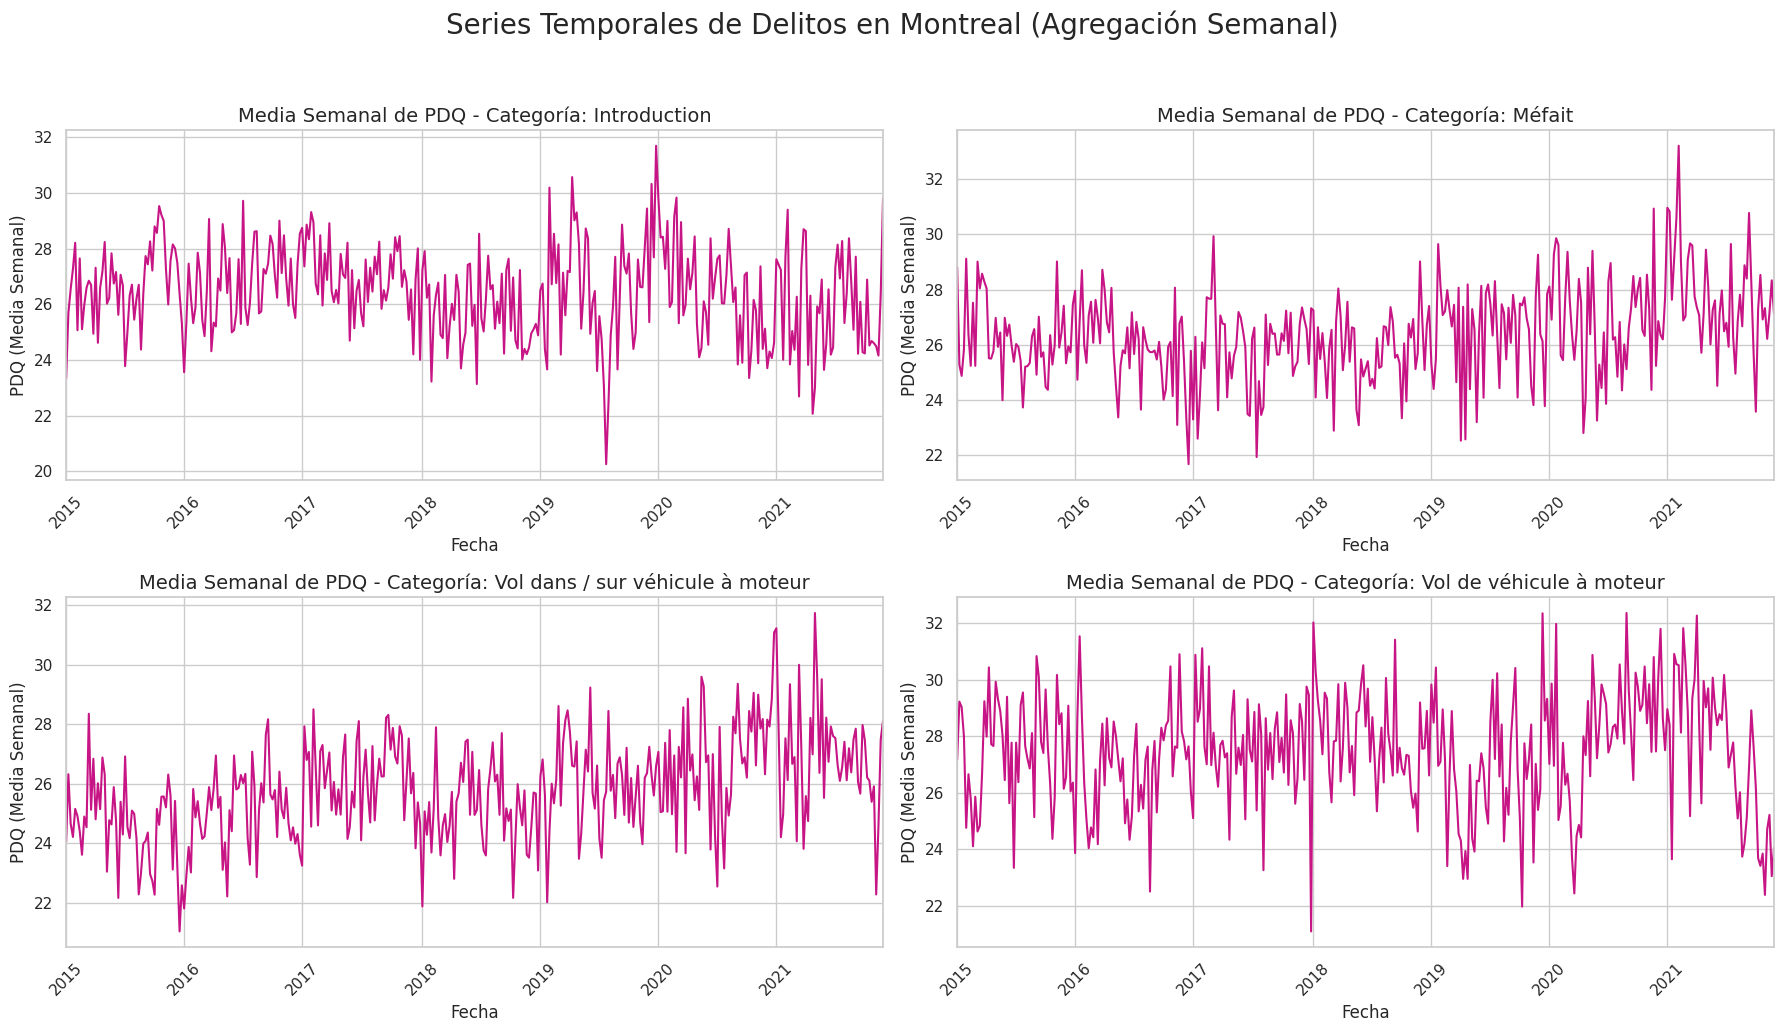

In [6]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()
all_series = [y_s1, y_s2, y_s3, y_s4]
titles = [
    f"Categoría: {validate_categorie[0]}",
    f"Categoría: {validate_categorie[1]}",
    f"Categoría: {validate_categorie[2]}",
    f"Categoría: {validate_categorie[3]}"
]

plot_color = 'mediumvioletred'
for i, (series_df, title) in enumerate(zip(all_series, titles)):

    series_df['pdq'].plot(
        ax=axes[i],
        color=plot_color,
        linestyle='-'
    )

    axes[i].set_title(f"Media Semanal de PDQ - {title}", fontsize=14)
    axes[i].set_ylabel('PDQ (Media Semanal)')
    axes[i].set_xlabel('Fecha')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Series Temporales de Delitos en Montreal (Agregación Semanal)", fontsize=20, y=1.03)
plt.tight_layout()
plt.show()

2. Escoger alguna serie temporal $y\_{si}, i =1,2,3,4$. Luego:

* Realizar un análisis exploratorio de la serie temporal escogida
* Aplicar el modelo de pronóstico $SARIMA(p,d,q)x(P,D,Q,S)$, probando varias configuraciones de los hiperparámetros. Encuentre la mejor configuración. Concluya.
* Para el mejor modelo encontrado, verificar si el residuo corresponde a un ruido blanco.

> **Hint**: Tome como `target_date` =  '2021-01-01'. Recuerde considerar que su columna de valores se llama `pdq`.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

max_date = y_s2.index.max()
target_date_EDA = '2020-01-01'

plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")
y_s2['pdq'].plot(title='Serie Temporal y_s2 (Media Semanal PDQ)', label='PDQ (Media Semanal)', color='mediumvioletred')
plt.axvline(pd.to_datetime(target_date_EDA), color='hotpink', linestyle='--', label=f'Inicio Set de Prueba ({target_date_EDA})')
plt.legend()
plt.savefig('y_s2_timeseries_plot.png')
plt.close()

warnings.filterwarnings("ignore", message="Could not determine frequency")
decomposition = seasonal_decompose(y_s2['pdq'].dropna(), model='additive', period=52)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
for ax in fig.get_axes():
    lines = ax.get_lines()
    if lines:
        lines[0].set_color('mediumvioletred')

plt.suptitle('Descomposición Estacional (S=52)', y=1.02)
plt.tight_layout()
plt.savefig('y_s2_decomposition.png')
plt.close()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y_s2['pdq'].dropna(), ax=ax1, lags=60,
         color='lightpink',
         vlines_kwargs={'colors': 'mediumvioletred'},
         markeredgecolor='mediumvioletred',
         markerfacecolor='mediumvioletred'
        )

plot_pacf(y_s2['pdq'].dropna(), ax=ax2, lags=60,
          color='lightpink',
          vlines_kwargs={'colors': 'mediumvioletred'},
          markeredgecolor='mediumvioletred',
          markerfacecolor='mediumvioletred'
         )

plt.tight_layout()
plt.savefig('y_s2_acf_pacf.png')
plt.close()

print("Gráficos ACF y PACF generados (con color rosado/magenta).")
print("Archivos guardados:")
print("1. 'y_s2_timeseries_plot.png'")
print("2. 'y_s2_decomposition.png'")
print("3. 'y_s2_acf_pacf_pink.png'")

Gráficos ACF y PACF generados (con color rosado/magenta).
Archivos guardados:
1. 'y_s2_timeseries_plot.png'
2. 'y_s2_decomposition.png'
3. 'y_s2_acf_pacf_pink.png'


In [8]:
# Creando la clase SarimaModels
class SarimaModels:
    def __init__(self, params):
        self.params = params

    @property
    def name_model(self):
        return f"SARIMA_{self.params[0]}X{self.params[1]}".replace(' ', '')

    @staticmethod
    def test_train_model(y, date):
        mask_ds = y.index < date
        y_train = y[mask_ds]
        y_test = y[~mask_ds]
        return y_train, y_test

    def fit_model(self, y, date):
        y_train, y_test = self.test_train_model(y, date)
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        model_fit = model.fit(disp=0)
        return model_fit

    def df_testing(self, y, date):
        y_train, y_test = self.test_train_model(y, date)
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        model_fit = model.fit(disp=0)
        start_index = y_test.index.min()
        end_index = y_test.index.max()
        preds = model_fit.get_prediction(start=start_index, end=end_index, dynamic=False)
        df_temp = pd.DataFrame({
            'y': y_test['pdq'],
            'yhat': preds.predicted_mean
        })
        return df_temp

    def metrics(self, y, date):
        df_temp = self.df_testing(y, date)
        df_metrics = regression_metrics(df_temp)
        df_metrics['model'] = self.name_model
        return df_metrics

# Definir parámetros
import itertools
p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]
params = list(itertools.product(pdq, seasonal_pdq))
target_date = '2021-01-01'

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

def regression_metrics(df_temp):
    df_temp = df_temp.dropna()
    rmse = np.sqrt(mean_squared_error(df_temp['y'], df_temp['yhat']))
    return pd.Series({'rmse': rmse})

target_date_SARIMA = '2020-01-01'
warnings.simplefilter('ignore')

results = []
for param in params:
    try:
        model_instance = SarimaModels(param)
        metrics = model_instance.metrics(y_s2, target_date_SARIMA)
        metrics['parameters'] = param
        results.append(metrics)
    except Exception as e:
        pass

if not results:
    print("No se pudo ajustar ningún modelo SARIMA.")
    best_params = None
else:
    df_results = pd.concat(results, axis=1).T.set_index('model')
    df_results = df_results.sort_values(by='rmse', ascending=True)
    print("\nMejores 5 Modelos (ordenados por RMSE)")
    print(df_results.head())
    best_params = df_results.iloc[0]['parameters']
    best_rmse = df_results.iloc[0]['rmse']
    print("\nConclusión:")
    print(f"La mejor configuración encontrada es SARIMA{best_params[0]}x{best_params[1]}")
    print(f"RMSE en el set de prueba: {best_rmse:.4f}")
    df_results.to_csv('sarima_grid_search_results.csv')
    print("Resultados completos de la búsqueda guardados en 'sarima_grid_search_results.csv'")


Mejores 5 Modelos (ordenados por RMSE)
                               rmse                  parameters
model                                                          
SARIMA_(0,1,0)X(1,0,1,12)  1.926367  ((0, 1, 0), (1, 0, 1, 12))
SARIMA_(0,1,0)X(0,0,1,12)   1.92783  ((0, 1, 0), (0, 0, 1, 12))
SARIMA_(0,1,0)X(0,0,0,12)  1.929611  ((0, 1, 0), (0, 0, 0, 12))
SARIMA_(0,1,0)X(1,0,0,12)   1.92977  ((0, 1, 0), (1, 0, 0, 12))
SARIMA_(0,1,0)X(1,1,1,12)  1.961788  ((0, 1, 0), (1, 1, 1, 12))

Conclusión:
La mejor configuración encontrada es SARIMA(0, 1, 0)x(1, 0, 1, 12)
RMSE en el set de prueba: 1.9264
Resultados completos de la búsqueda guardados en 'sarima_grid_search_results.csv'


In [10]:
#3
if best_params:
    best_model_instance = SarimaModels(best_params)
    best_model_fit = best_model_instance.fit_model(y_s2, target_date_SARIMA)
    fig = best_model_fit.plot_diagnostics(figsize=(15, 12))
    plt.suptitle(f"Diagnóstico de Residuos para {best_model_instance.name_model}", y=1.02)
    plt.tight_layout()
    plt.savefig('best_model_residuals.png')
    plt.close()

    print("Gráfico de diagnóstico de residuos guardado en 'best_model_residuals.png'")
else:
    print("No se encontró el mejor modelo, no se puede analizar los residuos.")

Gráfico de diagnóstico de residuos guardado en 'best_model_residuals.png'


3. Resuelva el ejercicio anterior utilizando la librería de `Prophet`.

In [11]:
pip install prophet --upgrade

In [12]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import warnings

prophet_df = y_s2.reset_index().rename(columns={'date': 'ds', 'pdq': 'y'})
target_date_prophet = '2020-01-01'
train_df = prophet_df[prophet_df['ds'] < target_date_prophet]
test_df = prophet_df[prophet_df['ds'] >= target_date_prophet]

print(f"Datos de entrenamiento: {train_df.shape[0]} semanas")
print(f"Datos de prueba: {test_df.shape[0]} semanas")
print("\nAjustando Modelo Base de Prophet")

model_base = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model_base.fit(train_df)
fig_comp = model_base.plot_components(model_base.predict(train_df))
plt.savefig('prophet_components_plot.png')
plt.close()

Datos de entrenamiento: 261 semanas
Datos de prueba: 100 semanas

Ajustando Modelo Base de Prophet


In [13]:
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 5.0, 10.0]
}

best_params = {}
best_rmse = float('inf')
results_prophet = []
for cp_scale in param_grid['changepoint_prior_scale']:
    for s_scale in param_grid['seasonality_prior_scale']:
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=cp_scale,
            seasonality_prior_scale=s_scale
        )
        model.fit(train_df)
        future_df = test_df[['ds']]
        forecast = model.predict(future_df)
        y_true = test_df['y']
        y_pred = forecast['yhat']
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        params_str = f"changepoint_prior: {cp_scale}, seasonality_prior: {s_scale}"
        print(f"Probando: {params_str} -> RMSE: {rmse:.4f}")
        results_prophet.append({'params': params_str, 'rmse': rmse})

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = {'changepoint_prior_scale': cp_scale, 'seasonality_prior_scale': s_scale}
print(f"Mejor configuración encontrada: {best_params}")
print(f"Mejor RMSE en el set de prueba: {best_rmse:.4f}")

Probando: changepoint_prior: 0.01, seasonality_prior: 1.0 -> RMSE: 2.0928
Probando: changepoint_prior: 0.01, seasonality_prior: 5.0 -> RMSE: 2.0535
Probando: changepoint_prior: 0.01, seasonality_prior: 10.0 -> RMSE: 2.0933
Probando: changepoint_prior: 0.1, seasonality_prior: 1.0 -> RMSE: 1.7830
Probando: changepoint_prior: 0.1, seasonality_prior: 5.0 -> RMSE: 1.7831
Probando: changepoint_prior: 0.1, seasonality_prior: 10.0 -> RMSE: 1.7831
Probando: changepoint_prior: 0.5, seasonality_prior: 1.0 -> RMSE: 1.7983
Probando: changepoint_prior: 0.5, seasonality_prior: 5.0 -> RMSE: 1.7978
Probando: changepoint_prior: 0.5, seasonality_prior: 10.0 -> RMSE: 1.7974
Mejor configuración encontrada: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}
Mejor RMSE en el set de prueba: 1.7830


Archivos guardados:
1. 'y_s2_timeseries_plot.png'
2. 'y_s2_decomposition.png'
3. 'y_s2_acf_pacf_pink.png'


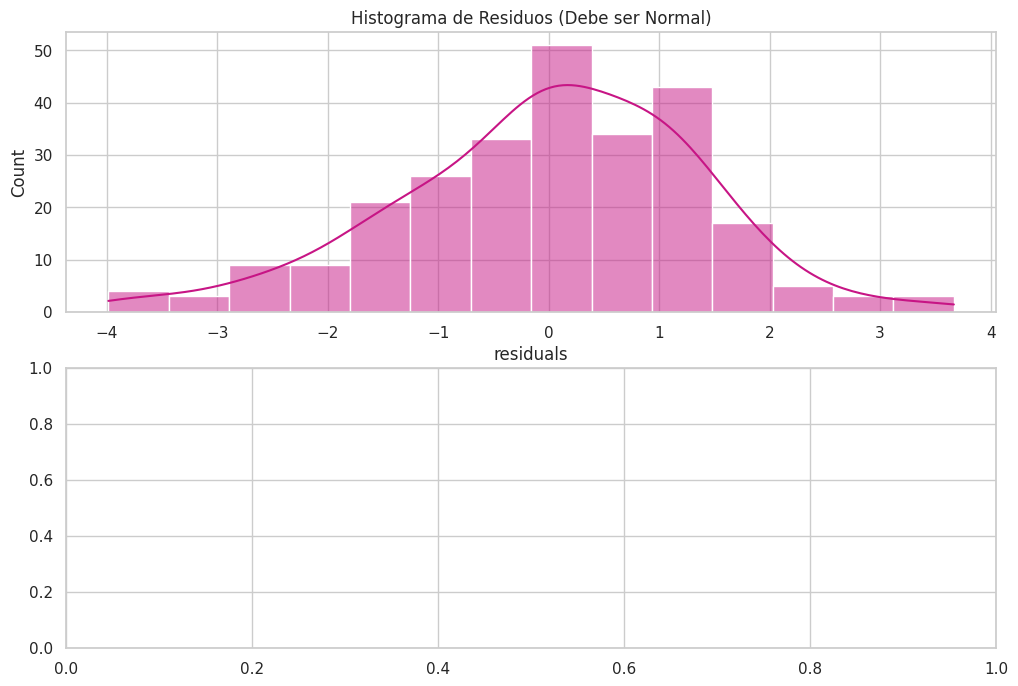

In [16]:
best_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    **best_params
)
best_model.fit(train_df)

train_forecast = best_model.predict(train_df)
residuals_df = train_df.set_index('ds').join(train_forecast.set_index('ds')[['yhat']])
residuals_df['residuals'] = residuals_df['y'] - residuals_df['yhat']
residuals_df = residuals_df.dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
sns.histplot(residuals_df['residuals'], kde=True, ax=ax1, color='mediumvioletred')
ax1.set_title('Histograma de Residuos')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y_s2['pdq'].dropna(), ax=ax1, lags=60,
         color='lightpink',
         vlines_kwargs={'colors': 'mediumvioletred'},
         markeredgecolor='mediumvioletred',
         markerfacecolor='mediumvioletred'
        )

plot_pacf(y_s2['pdq'].dropna(), ax=ax2, lags=60,
          color='lightpink',
          vlines_kwargs={'colors': 'mediumvioletred'},
          markeredgecolor='mediumvioletred',
          markerfacecolor='mediumvioletred'
         )

plt.tight_layout()
plt.savefig('y_s2_acf_pacf_pink.png')
plt.close()
print("Archivos guardados:")
print("1. 'y_s2_timeseries_plot.png'")
print("2. 'y_s2_decomposition.png'")
print("3. 'y_s2_acf_pacf_pink.png'")